# Complex branches: turns, loops, retrograde motion, and mixed futures

This tutorial shows how to interpret biologically unusual velocity fields
without forcing every annotated branch into a monotonic outward ray.

The core distinction is:

- **Conditional Fate Affinity (CFA)** describes future identity;
- **Discounted Fate Reach (DFR)** describes how much selected-fate probability is resolved;
- **Future-Fate Specificity (FFS)** describes decisiveness;
- **Signed Ordering Flux (SOF)** describes forward or retrograde movement.

A branch can have high CFA for its annotated fate and negative or sign-changing
SOF. That is not a contradiction.

## 1. Imports and synthetic archetypes

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scCS

SEED = 20260714
rng = np.random.default_rng(SEED)
plt.rcParams["figure.dpi"] = 110

print("scCS", scCS.__version__)

scCS 0.8.0.dev34


## 2. Formal separation of identity and motion

DFFP fate identity is based on the conditional probability vector $q_i$. Signed Ordering Flux uses the supplied ordering $s$:

$$
\widetilde P_{ij}=\frac{P_{ij}}{\sum_{k\in S}P_{ik}},\qquad
g_i=\sum_{j\in S}\widetilde P_{ij}(s_j-s_i).
$$

There is no equation requiring high $q_{if}$ to imply positive $g_i$. A cell may retain high affinity for fate $f$ while returning toward an earlier state, following a loop, or turning across the embedding.

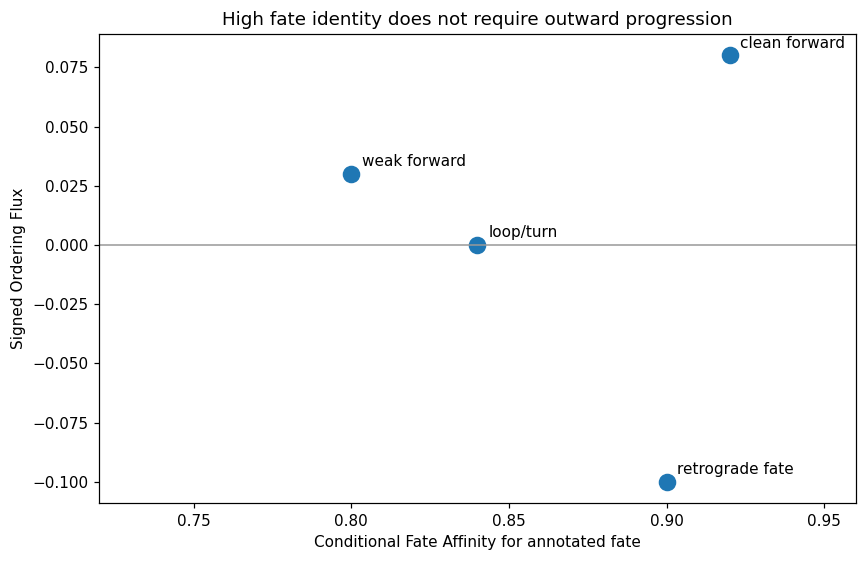

In [2]:
identity_motion = pd.DataFrame(
    {
        "CFA for annotated fate": [0.92, 0.90, 0.84, 0.80],
        "SOF": [0.08, -0.10, 0.00, 0.03],
        "case": ["clean forward", "retrograde fate", "loop/turn", "weak forward"],
    }
)
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.scatter(identity_motion["CFA for annotated fate"], identity_motion["SOF"], s=110)
for _, row in identity_motion.iterrows():
    ax.annotate(
        row["case"],
        (row["CFA for annotated fate"], row["SOF"]),
        xytext=(7, 5),
        textcoords="offset points",
    )
ax.axhline(0, color="0.6", linewidth=1)
ax.set_xlim(0.72, 0.96)
ax.set_xlabel("Conditional Fate Affinity for annotated fate")
ax.set_ylabel("Signed Ordering Flux")
ax.set_title("High fate identity does not require outward progression")
fig.tight_layout()
plt.show()

## 3. Branch-relative display angles

For a display velocity $v_i$, decompose it into components parallel and perpendicular to the annotated branch direction $d_f$:

$$
v_{\parallel}=v_i^\top d_f,\qquad
v_{\perp}=v_i-v_{\parallel}d_f,\qquad
\theta_i=\operatorname{atan2}(\|v_{\perp}\|,v_{\parallel}).
$$

Thus $0^\circ$ is outward, $180^\circ$ is inward, and $\pm90^\circ$ is transverse. These angles are display diagnostics only; DFFP remains defined on the source graph.

In [3]:
t = np.linspace(0.0, 1.0, 120)

archetypes = {
    "clean forward": {
        "x": t,
        "y": np.zeros_like(t),
        "flux": 0.08 + 0.02 * np.sin(np.pi * t),
        "affinity": 0.90 + 0.05 * t,
        "reach": 0.55 + 0.35 * t,
    },
    "retrograde fate": {
        "x": t,
        "y": 0.05 * np.sin(np.pi * t),
        "flux": -0.04 - 0.10 * t,
        "affinity": 0.82 + 0.10 * t,
        "reach": 0.45 + 0.30 * t,
    },
    "turning branch": {
        "x": t,
        "y": 0.45 * np.sin(np.pi * t),
        "flux": 0.11 * np.cos(np.pi * t),
        "affinity": 0.78 + 0.08 * np.sin(np.pi * t),
        "reach": 0.40 + 0.40 * t,
    },
    "loop-like branch": {
        "x": 0.55 + 0.38 * np.cos(2 * np.pi * t),
        "y": 0.38 * np.sin(2 * np.pi * t),
        "flux": 0.13 * np.cos(2 * np.pi * t),
        "affinity": 0.74 + 0.12 * np.cos(np.pi * (t - 0.5)),
        "reach": 0.35 + 0.35 * t,
    },
}
for values in archetypes.values():
    values["specificity"] = np.clip(
        0.15 + 0.85 * (values["affinity"] - 0.25) / 0.75,
        0,
        1,
    )
    values["resolved"] = values["reach"] * values["specificity"]

## 4. Source-space velocity archetypes

Arrows show local motion in the source manifold. The branch annotation does not
guarantee that every arrow points toward larger ordering values.

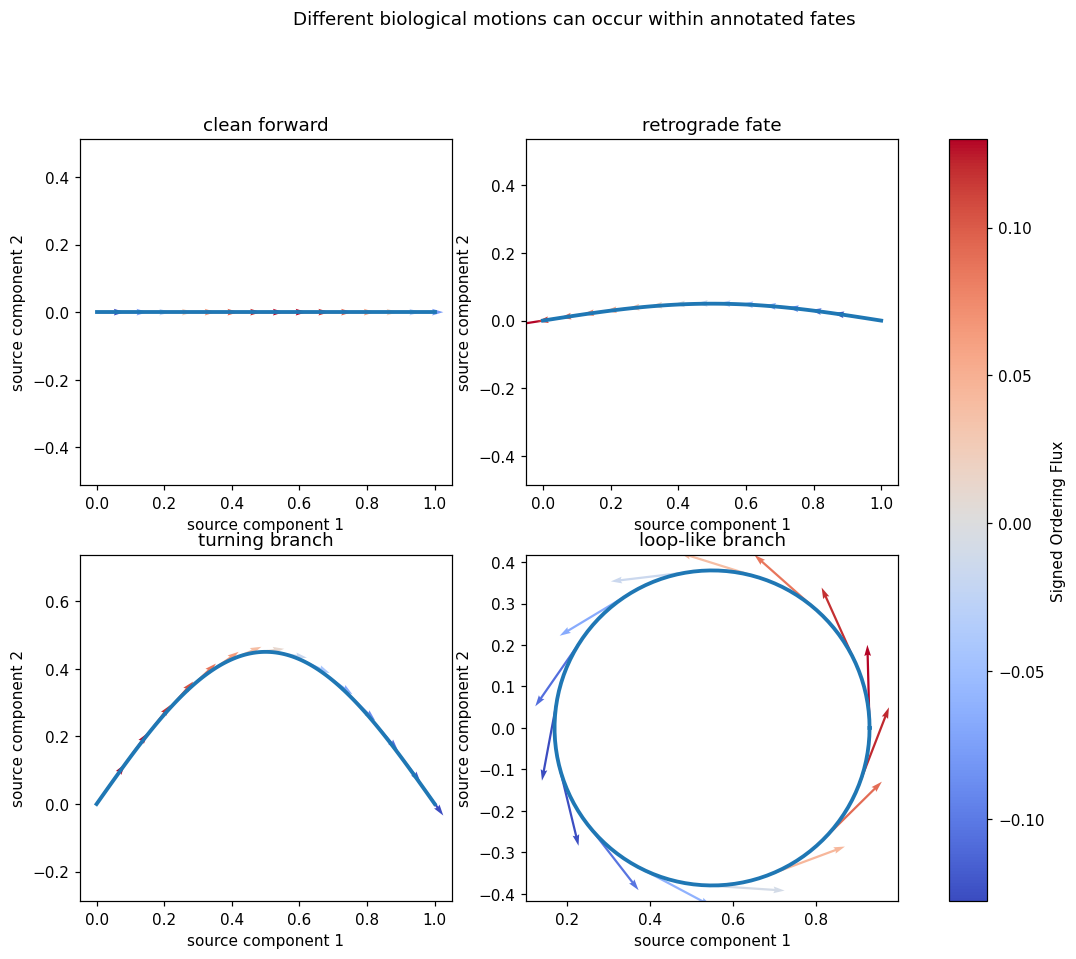

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for axis, (name, values) in zip(axes.ravel(), archetypes.items()):
    x = values["x"]
    y = values["y"]
    dx = np.gradient(x)
    dy = np.gradient(y)
    if name == "retrograde fate":
        dx = -np.abs(dx)
        dy = -dy
    sample = np.arange(0, len(t), 8)
    axis.plot(x, y, linewidth=2.5)
    arrows = axis.quiver(
        x[sample],
        y[sample],
        dx[sample],
        dy[sample],
        values["flux"][sample],
        cmap="coolwarm",
        angles="xy",
        scale_units="xy",
        scale=0.10,
        width=0.006,
    )
    axis.set_title(name)
    axis.set_xlabel("source component 1")
    axis.set_ylabel("source component 2")
    axis.set_aspect("equal", adjustable="datalim")
fig.colorbar(arrows, ax=axes.ravel().tolist(), label="Signed Ordering Flux")
fig.suptitle("Different biological motions can occur within annotated fates", y=1.01)
plt.show()

## 5. Identity, resolution, and progression along ordering

High affinity does not imply positive progression. The turning and loop-like
examples keep a coherent future identity while SOF changes sign.

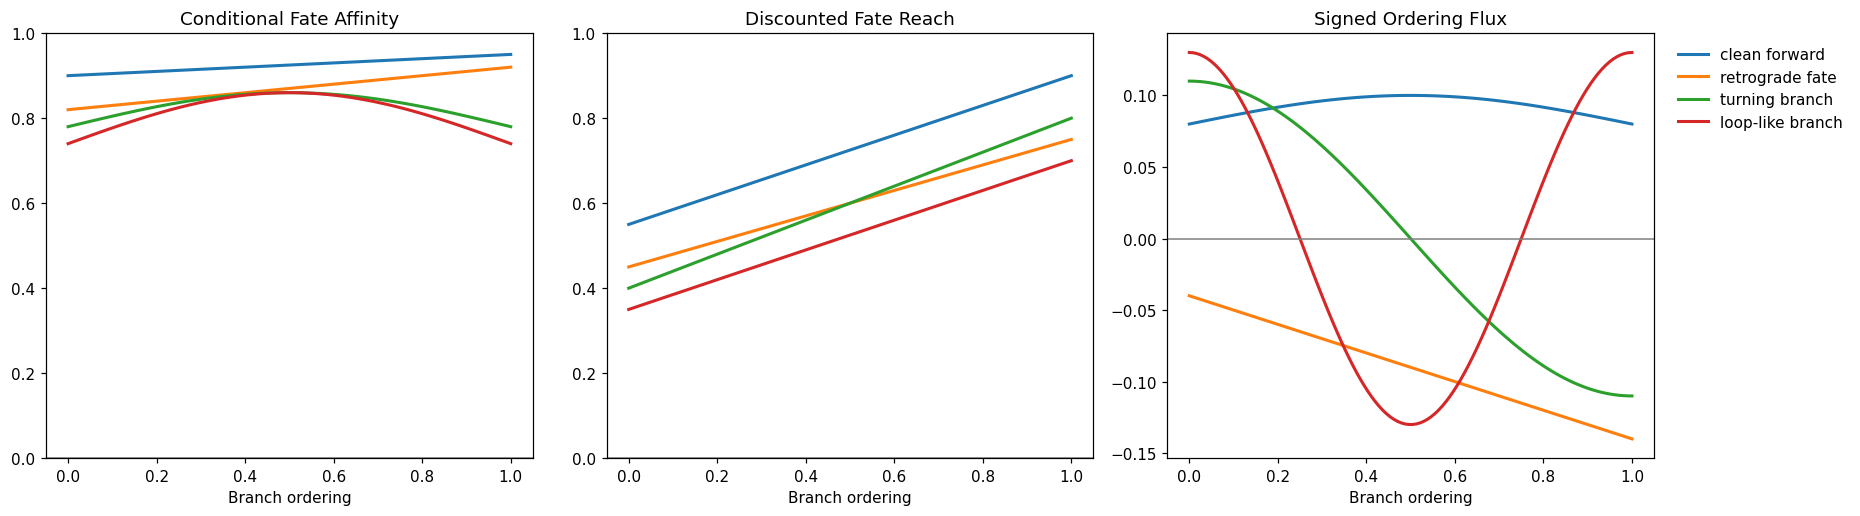

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for name, values in archetypes.items():
    axes[0].plot(t, values["affinity"], linewidth=2, label=name)
    axes[1].plot(t, values["reach"], linewidth=2, label=name)
    axes[2].plot(t, values["flux"], linewidth=2, label=name)
axes[0].set_title("Conditional Fate Affinity")
axes[1].set_title("Discounted Fate Reach")
axes[2].set_title("Signed Ordering Flux")
for axis in axes:
    axis.set_xlabel("Branch ordering")
    axis.axhline(0, color="0.5", linewidth=1)
axes[0].set_ylim(0, 1)
axes[1].set_ylim(0, 1)
axes[2].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## 6. A two-axis interpretation map

DFR and FFS answer different questions. Color adds SOF:

- upper right: resolved and specific;
- upper left: specific but weakly reached;
- lower right: reached but fate-ambiguous;
- lower left: unresolved and ambiguous.

Negative color does not invalidate a point; it indicates retrograde motion.

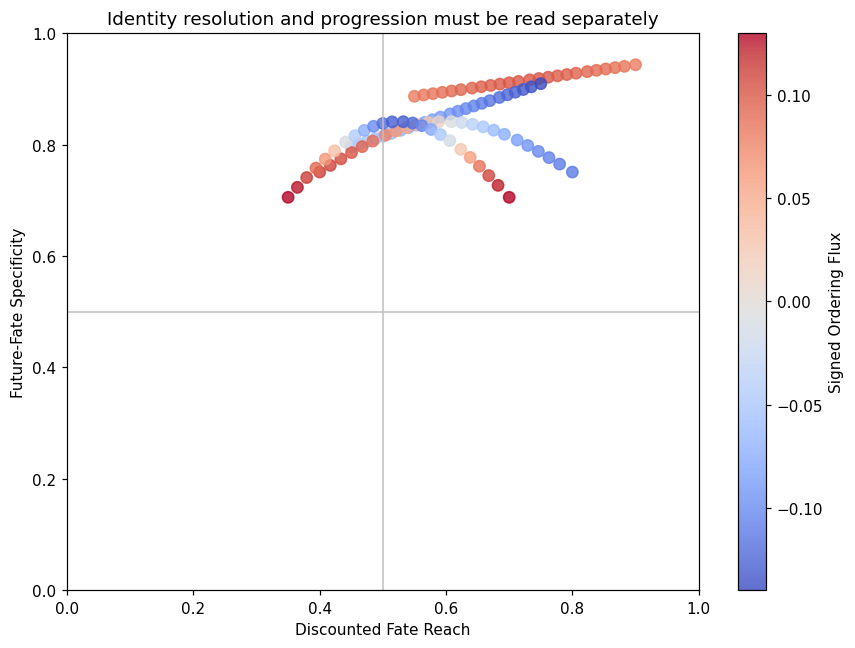

In [6]:
rows = []
for name, values in archetypes.items():
    for index in np.linspace(0, len(t) - 1, 24).astype(int):
        rows.append(
            {
                "archetype": name,
                "reach": values["reach"][index],
                "specificity": values["specificity"][index],
                "flux": values["flux"][index],
            }
        )
map_table = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    map_table["reach"],
    map_table["specificity"],
    c=map_table["flux"],
    cmap="coolwarm",
    s=55,
    alpha=0.8,
)
ax.axvline(0.5, color="0.75", linewidth=1)
ax.axhline(0.5, color="0.75", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Discounted Fate Reach")
ax.set_ylabel("Future-Fate Specificity")
ax.set_title("Identity resolution and progression must be read separately")
fig.colorbar(scatter, ax=ax, label="Signed Ordering Flux")
fig.tight_layout()
plt.show()

## 7. Branch-relative velocity-angle profiles

For a terminal branch, \(0^\circ\) is outward, \(180^\circ\) is inward, and
\(\pm90^\circ\) is transverse. These profiles are display diagnostics; they do
not replace DFFP.

The synthetic distributions below show how clean, retrograde, turning, and
loop-like branches appear when referenced to their own branch axes.

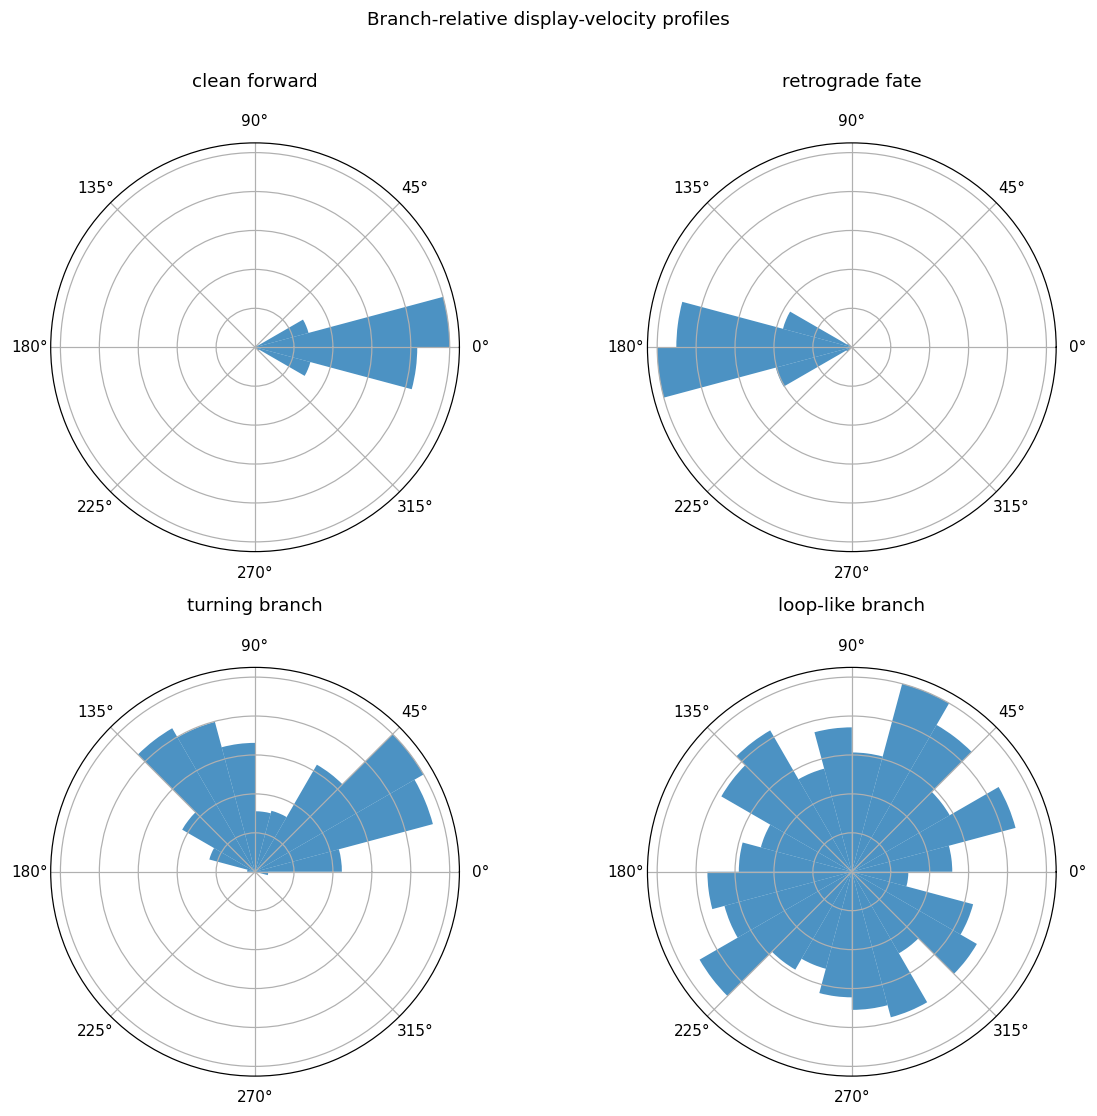

In [7]:
angle_samples = {
    "clean forward": rng.normal(0.0, 12.0, 500),
    "retrograde fate": rng.normal(180.0, 14.0, 500),
    "turning branch": np.r_[
        rng.normal(35.0, 18.0, 250),
        rng.normal(120.0, 22.0, 250),
    ],
    "loop-like branch": rng.uniform(-180.0, 180.0, 500),
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 10),
    subplot_kw={"projection": "polar"},
)
bins = np.linspace(-np.pi, np.pi, 25)
for axis, (name, degrees) in zip(axes.ravel(), angle_samples.items()):
    radians = np.deg2rad(((degrees + 180) % 360) - 180)
    counts, edges = np.histogram(radians, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    width = np.diff(edges)
    axis.bar(centers, counts / max(counts.max(), 1), width=width, alpha=0.8)
    axis.set_theta_zero_location("E")
    axis.set_theta_direction(1)
    axis.set_title(name, pad=18)
    axis.set_yticklabels([])
fig.suptitle("Branch-relative display-velocity profiles", y=1.01)
fig.tight_layout()
plt.show()

## 8. Anchor diagnostics are context, not monotonicity gates

The pancreas benchmark contained strong sink-like Alpha and Beta endpoints,
whereas Delta and Epsilon retained substantial transition mass toward other
states. Gut in the Schwann benchmark remained annotation-coherent but showed
retrograde SOF.

The stacked bars below illustrate the diagnostic quantities that should be
reported.

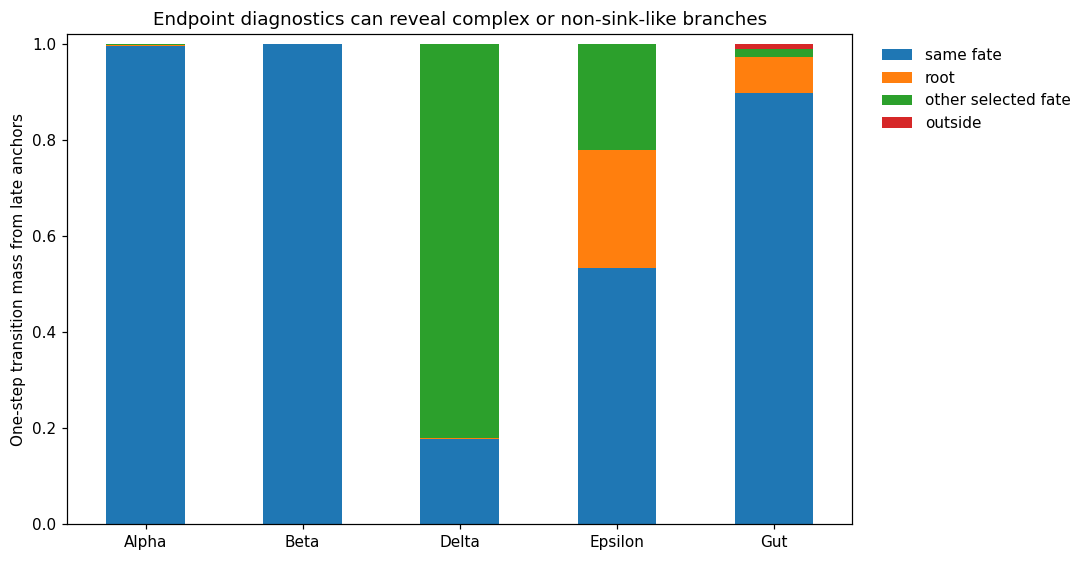

,same fate,root,other selected fate,outside
Alpha,0.996,0.001,0.003,0.000
Beta,1.000,0.000,0.000,0.000
Delta,0.178,0.001,0.821,0.000
Epsilon,0.534,0.245,0.220,0.001
Gut,0.898,0.074,0.018,0.010


In [8]:
anchor_example = pd.DataFrame(
    {
        "same fate": [0.996, 1.000, 0.178, 0.534, 0.898],
        "root": [0.001, 0.000, 0.001, 0.245, 0.074],
        "other selected fate": [0.003, 0.000, 0.821, 0.220, 0.018],
        "outside": [0.000, 0.000, 0.000, 0.001, 0.010],
    },
    index=["Alpha", "Beta", "Delta", "Epsilon", "Gut"],
)
ax = anchor_example.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5.2),
    ylabel="One-step transition mass from late anchors",
    title="Endpoint diagnostics can reveal complex or non-sink-like branches",
)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
anchor_example

## 9. Summarizing real scCS results

In [9]:
def summarize_branches(result, annotations):
    table = pd.DataFrame(
        {
            "annotation": np.asarray(annotations).astype(str),
            "DFR": result.discounted_fate_reach,
            "FFS": result.future_fate_specificity,
            "RC": result.resolved_commitment,
            "SOF": result.signed_ordering_flux,
        }
    )
    for fate_index, fate in enumerate(result.fate_names):
        table[f"CFA:{fate}"] = result.conditional_fate_affinity[:, fate_index]
    return table.groupby("annotation", observed=True).agg(
        n_cells=("DFR", "size"),
        mean_DFR=("DFR", "mean"),
        mean_FFS=("FFS", "mean"),
        mean_RC=("RC", "mean"),
        mean_SOF=("SOF", "mean"),
        forward_fraction=("SOF", lambda values: float(np.mean(values > 0))),
    )


def add_ordering_thirds(frame, ordering_column):
    output = frame.copy()
    output["ordering_third"] = "middle"
    for annotation, indices in output.groupby("annotation", observed=True).groups.items():
        ranks = output.loc[indices, ordering_column].rank(method="first", pct=True)
        output.loc[indices, "ordering_third"] = pd.cut(
            ranks,
            bins=[0, 1 / 3, 2 / 3, 1],
            labels=["early", "middle", "late"],
            include_lowest=True,
        ).astype(str)
    return output

## 10. Interpretation checklist

1. Inspect the native velocity field before the star.
2. Read CFA, DFR, FFS, and RC before display-space arrows.
3. Interpret SOF independently from fate identity.
4. Use ordering thirds to distinguish uniformly retrograde motion from a turn or loop.
5. Report weak sink behavior, but do not relabel it as a software failure.
6. Restrict hard dominant-fate labels when specificity or the probability margin is low.
7. Remember that display velocity profiles are qualitative QC and DFFP remains the scientific score.